# Task 4 — SVC Model Training

**Goal:** Train a Support Vector Classifier (SVC) on the scaled, correlation-filtered feature matrix. Use stratified cross-validation to tune hyperparameters, then save the best model for evaluation in Task 5.

**Input:** `data/processed/X_scaled.npy`, `y.npy`, `feature_names.npy`  
**Output:** `data/processed/svc_model.pkl`, `data/processed/scaler.pkl`

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

## 1. Load Data

In [10]:
# Load unscaled cleaned data and the surviving feature names from Task 3.
# We re-apply scaling here on training data only to avoid leakage.
df = pd.read_csv('../data/processed/compounds_clean.csv')
feature_names = np.load('../data/processed/feature_names.npy', allow_pickle=True)

# Keep only the correlation-filtered features selected in Task 3
X_raw = df[feature_names].values
y     = df['Class'].values
cid   = df['CID'].values

print(f'X shape      : {X_raw.shape}')
print(f'y shape      : {y.shape}')
print(f'Features     : {len(feature_names)}')
print(f'Class counts : inactive={(y==0).sum()}  active={(y==1).sum()}')

X shape      : (243, 206)
y shape      : (243,)
Features     : 206
Class counts : inactive=72  active=171


## 2. Train / Test Split

We hold out 20% of compounds as a test set that the model never sees during training or tuning. `stratify=y` ensures both splits preserve the ~30/70 class ratio — without this, random chance could put all inactive compounds in one split.

In [11]:
# Split on raw data first — scaler must not see test set during fitting
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data only, then apply to both splits.
# Fitting on all data (including test) would leak test statistics into the model — data leakage.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # transform only on test

print(f'Train : {X_train.shape[0]} compounds  (inactive={(y_train==0).sum()}, active={(y_train==1).sum()})')
print(f'Test  : {X_test.shape[0]} compounds   (inactive={(y_test==0).sum()}, active={(y_test==1).sum()})')

Train : 194 compounds  (inactive=57, active=137)
Test  : 49 compounds   (inactive=15, active=34)


## 3. Hyperparameter Tuning with GridSearchCV

An SVC with an RBF kernel has two key hyperparameters:
- **C** — regularization strength. High C = fits training data closely (risk of overfitting). Low C = smoother boundary (risk of underfitting).
- **gamma** — how far each training compound's influence reaches. High gamma = tight, complex boundaries. Low gamma = broad, smooth boundaries.

We search a grid of combinations using 5-fold stratified cross-validation on the training set only — the test set stays untouched until Task 5.

`class_weight='balanced'` tells the SVC to penalize mistakes on the minority class (inactive, 30%) more heavily, compensating for the class imbalance.

In [12]:
# Parameter grid to search — each combination is evaluated via cross-validation
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
}

# StratifiedKFold ensures each fold preserves the class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# f1_weighted accounts for class imbalance better than plain accuracy
grid_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,   # use all CPU cores
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV F1  : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'C': 10, 'gamma': 0.001}
Best CV F1  : 1.0000


## 4. Visualise the Grid Search Results

Heatmap of mean cross-validation F1 score across all C × gamma combinations — helps confirm the best region isn't at an edge of the grid (which would suggest we need to expand the search range).

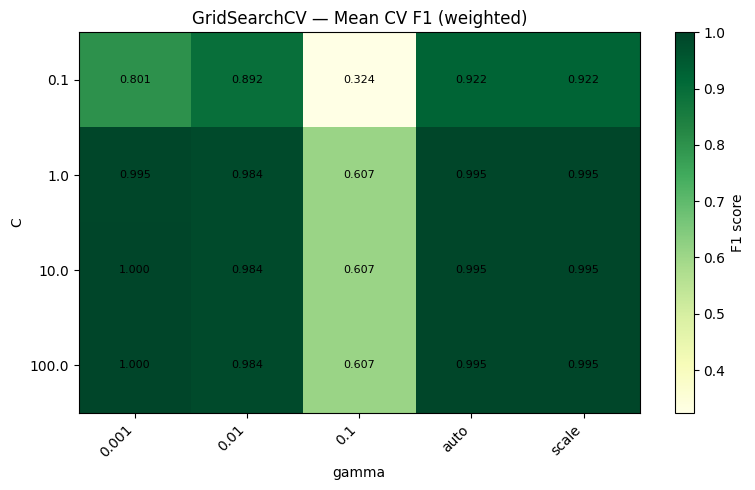

In [13]:
results = pd.DataFrame(grid_search.cv_results_)

# Pivot to C × gamma grid for the heatmap
pivot = results.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('GridSearchCV — Mean CV F1 (weighted)')
plt.colorbar(im, ax=ax, label='F1 score')

# Annotate each cell with its score
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train Final Model

Refit the SVC using the best hyperparameters found above on the full training set (GridSearchCV's `best_estimator_` is already refitted, so we just extract it).

In [14]:
# best_estimator_ is already refitted on the full training set by GridSearchCV
best_svc = grid_search.best_estimator_

# Quick sanity check on the training set — expect near-perfect score (model has seen this data)
train_score = best_svc.score(X_train, y_train)
print(f'Training accuracy : {train_score:.4f}')
print(f'Best params       : {grid_search.best_params_}')

Training accuracy : 1.0000
Best params       : {'C': 10, 'gamma': 0.001}


## 6. Preview on Test Set

A quick look at test performance before the full evaluation in Task 5. The confusion matrix shows counts of true positives, true negatives, false positives, and false negatives.

              precision    recall  f1-score   support

Inactive (0)       1.00      1.00      1.00        15
  Active (1)       1.00      1.00      1.00        34

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



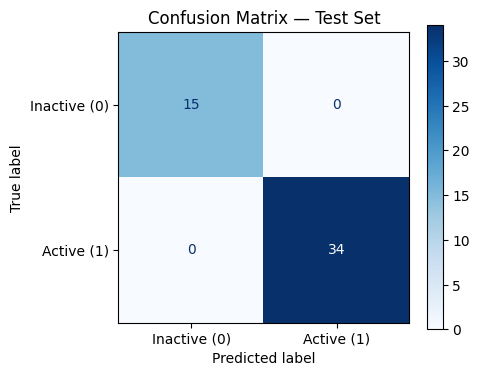

In [15]:
y_pred = best_svc.predict(X_test)

# classification_report gives precision, recall, F1 per class
print(classification_report(y_test, y_pred, target_names=['Inactive (0)', 'Active (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Inactive (0)', 'Active (1)'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Model

In [16]:
# Save both the model and the scaler — Task 6 needs the scaler to transform
# new PubChem compounds using the same mean/std learned from training data
joblib.dump(best_svc, '../data/processed/svc_model.pkl')
joblib.dump(scaler,   '../data/processed/scaler.pkl')

print('Saved: data/processed/svc_model.pkl')
print('Saved: data/processed/scaler.pkl')

Saved: data/processed/svc_model.pkl
Saved: data/processed/scaler.pkl
